# Qual classificação climática serve melhor de base para estimar SOC e textura?

Comparação de três sistemas de classificação climática gerados a partir do CHELSA V2.1 (normal 1991-2020)
— **Köppen-Geiger**, **Holdridge** e **Thornthwaite** (com CAD de 100 mm e CAD do solo) — tendo o
**Köppen IPEF** (o que vem nas matrizes do MapBiomas Solo C3) como referência. Variáveis de solo na camada
de 0-30 cm: estoque de carbono orgânico (SOC) e as frações areia, silte e argila.

**Resposta curta** (detalhes e ressalvas nas seções 4 a 8):

- **Não há um sistema melhor para tudo.** A melhor base depende da variável:
  - **SOC → Holdridge L2 (zona de vida).** Empata com Thornthwaite L1 e Köppen IPEF L3 quando o teste é
    perto do treino (blocos de 1° e 2°) e é o melhor quando o teste é longe (blocos de 5°) — o mais robusto.
  - **Textura → Thornthwaite L2 (umidade + subtipo).** Em silte vence todos os sistemas em qualquer escala
    (R² 0,20 contra 0,15 do melhor Köppen). Em areia lidera a curta distância, mas o sinal é fraco e some a 5°.
- **A CAD do BHC não importa:** CAD 100 mm e CAD do solo dão praticamente o mesmo resultado.
- **Köppen CHELSA fica sempre abaixo do Köppen IPEF**, apesar de usar dados climáticos mais recentes.
- **Nenhuma classificação climática estima argila** fora da amostra, e para SOC todas explicam pouco
  (R² espacial ≤ 0,10). Classe climática sozinha é uma base fraca; a escolha entre sistemas importa menos
  do que parece.

## 1. A pergunta certa: não é "correlação"

A pergunta — qual classificação climática serve melhor de base para estimar SOC e textura — pede três
ajustes antes de escolher uma métrica:

1. **Não é correlação no sentido estrito.** Clima em classes é uma variável nominal: Pearson e Spearman
   não se aplicam, e o ponto-bisserial mede uma classe de cada vez, não o sistema inteiro. O que dá para
   medir é **quanto da variação de SOC e textura cada classificação explica**.
2. **Os sistemas não têm o mesmo número de classes.** Aqui vão de 3 (Köppen L1) a 32 (Thornthwaite L3).
   Mais classes sempre explicam mais *dentro* da amostra, mesmo que não carreguem informação nenhuma. A
   métrica precisa penalizar isso — senão ganha quem tem mais classes.
3. **Com ~12 mil locais, qualquer teste dá p < 0,001.** Kruskal-Wallis e ANOVA seriam "significativos"
   para todos os sistemas e não ajudariam a escolher. Por isso não há p-valores nesta análise.

## 2. A métrica: R² fora da amostra, com validação em blocos espaciais

Cada classificação é usada como **único preditor**: a estimativa de um local é a **média da sua classe**,
calculada só com os locais de treino. Mede-se o R² nos locais de teste:

$$R^2 = 1 - \frac{\sum (y - \hat{y})^2}{\sum (y - \bar{y})^2}$$

Os locais de teste são separados em **blocos espaciais** (quadrículas de 2°, principal; 1° e 5° como
sensibilidade), sorteados em 5 dobras e repetidos 50 vezes. Por que essa métrica:

- **Mede exatamente o que se quer:** o quanto a classificação ajuda a estimar SOC e textura num lugar onde
  não há amostra.
- **Penaliza classes demais sozinha:** uma classe pequena ou sem informação tem média instável e piora o
  R² no teste. O R² fora da amostra pode até ficar **negativo** — significa que usar a média da classe
  estima *pior* do que usar a média geral do Brasil.
- **Os blocos espaciais evitam R² inflado:** locais vizinhos são parecidos (autocorrelação espacial); com
  dobras aleatórias, o teste sempre tem um vizinho no treino e o R² fica otimista.
- **Mesma escala e mesmas dobras para todos:** os sistemas são avaliados nos mesmos locais e nas mesmas
  dobras em cada repetição, então a diferença de R² entre dois sistemas é **pareada**. Dá para dizer se
  uma vantagem é consistente (aparece em quase todas as repetições) ou é ruído do sorteio dos blocos.

Complemento descritivo: **ω² (ômega-quadrado)**, o tamanho de efeito da ANOVA de um fator — a fração da
variância explicada pelas classes *dentro da amostra*, já descontado o ganho que se teria só por haver k
classes (ao contrário do η², que sempre cresce com k).

**Como ler:** R² espacial é a métrica de decisão; ω² descreve a associação. SOC entra como **log(SOC)**,
porque o estoque é muito assimétrico; as frações de textura, em %.

In [1]:
from pathlib import Path
import os

# Roda de dentro da pasta corelacao/ mesmo que o kernel tenha começado na pasta pai.
if not Path('resultados/tabelas').exists() and Path('corelacao/resultados/tabelas').exists():
    os.chdir('corelacao')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
TAB = Path('resultados/tabelas')
amostra = pd.read_csv(TAB / 'amostra.csv')
desemp = pd.read_csv(TAB / 'desempenho.csv')
difs = pd.read_csv(TAB / 'diferencas_pareadas.csv')
classes = pd.read_csv(TAB / 'classes.csv')

RESPOSTAS = {'log_soc': 'log(SOC)', 'argila': 'Argila (%)', 'areia': 'Areia (%)', 'silte': 'Silte (%)'}
SISTEMAS = ['Köppen IPEF (referência)', 'Köppen CHELSA', 'Holdridge CHELSA',
            'Thornthwaite CAD 100 mm', 'Thornthwaite CAD do solo']
CORES = {'Köppen IPEF (referência)': '#8c8c8c', 'Köppen CHELSA': '#2a78d6', 'Holdridge CHELSA': '#eb6834',
         'Thornthwaite CAD 100 mm': '#1baf7a', 'Thornthwaite CAD do solo': '#eda100'}
TINTA, TINTA2, GRADE = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({'font.size': 10, 'axes.edgecolor': TINTA2, 'axes.labelcolor': TINTA,
                     'xtick.color': TINTA2, 'ytick.color': TINTA2, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.facecolor': 'white'})

## 3. Dados e sistemas comparados

**Locais:** duas matrizes de pontos do MapBiomas Solo C3 (acesso restrito), limpas e agregadas por local
(uma linha por coordenada; pseudoamostras e amostras artificiais excluídas; textura só em 0-30 cm e com as
frações fechando 100%). Um local só entra se tiver classe em **todos** os sistemas e níveis — os ~1% que
ficam de fora estão no litoral ou em corpos d'água, onde algum raster CHELSA ou o AWC não tem valor.

In [2]:
display(amostra.rename(columns={'locais': 'locais na amostra comum',
                                 'excluidos_sem_classe': 'sem classe em algum sistema'}))

niveis = (desemp[desemp.resposta == 'log_soc'][['sistema', 'nivel', 'descricao', 'n_classes']]
          .rename(columns={'n_classes': 'classes presentes (SOC)'}))
display(niveis.reset_index(drop=True))

,resposta,rotulo,locais na amostra comum,sem classe em algum sistema,blocos_bloco_1,blocos_bloco_2,blocos_bloco_5
0,log_soc,log(SOC),12151,135,650,200,44
1,argila,Argila (%),11934,128,636,197,44
2,areia,Areia (%),11934,128,636,197,44
3,silte,Silte (%),11934,128,636,197,44


,sistema,nivel,descricao,classes presentes (SOC)
0,Köppen IPEF (referência),L1,"grupo (A, B, C)",3
1,Köppen IPEF (referência),L2,"tipo (Af, Am, Aw, Cf...)",8
2,Köppen IPEF (referência),L3,"subtipo (Cfa, Cfb...)",10
3,Köppen CHELSA,L1,"grupo (A, B, C)",3
4,Köppen CHELSA,L2,"tipo (Af, Am, Aw, Cf...)",8
5,Köppen CHELSA,L3,"classe completa (Aw, Cfa...)",10
6,Holdridge CHELSA,L1,faixa térmica,4
7,Holdridge CHELSA,L2,zona de vida,15
8,Thornthwaite CAD 100 mm,L1,classe de umidade,9
9,Thornthwaite CAD 100 mm,L2,umidade + subtipo,26


- **Köppen IPEF (referência):** o que vem nas matrizes, como dummies. No L3, os locais do grupo A
  recebem o próprio tipo (Af, Am, As, Aw), que já é a classe completa — assim o L3 do IPEF equivale ao L3
  do Köppen CHELSA.
- **Holdridge CHELSA:** L1 = faixa térmica (biotemperatura), L2 = zona de vida. As zonas são rotuladas pela
  faixa térmica e pela razão ETP/P, que é o que a tabela de classificação usa.
- **Thornthwaite CHELSA:** L1 = classe de umidade (A a E), L2 = + subtipo (r, s, w, d...), L3 = tipo
  completo. Com ETP de Penman-Monteith, quase todo o Brasil é A'a' nas duas últimas letras; por isso L3
  quase não difere de L2.

## 4. Resultado principal: R² espacial de cada sistema

Cada ponto é o R² médio fora da amostra (blocos de 2°) e a barra, o intervalo de 95% entre as 50
repetições do sorteio dos blocos. A linha tracejada marca o melhor preditor de cada variável.

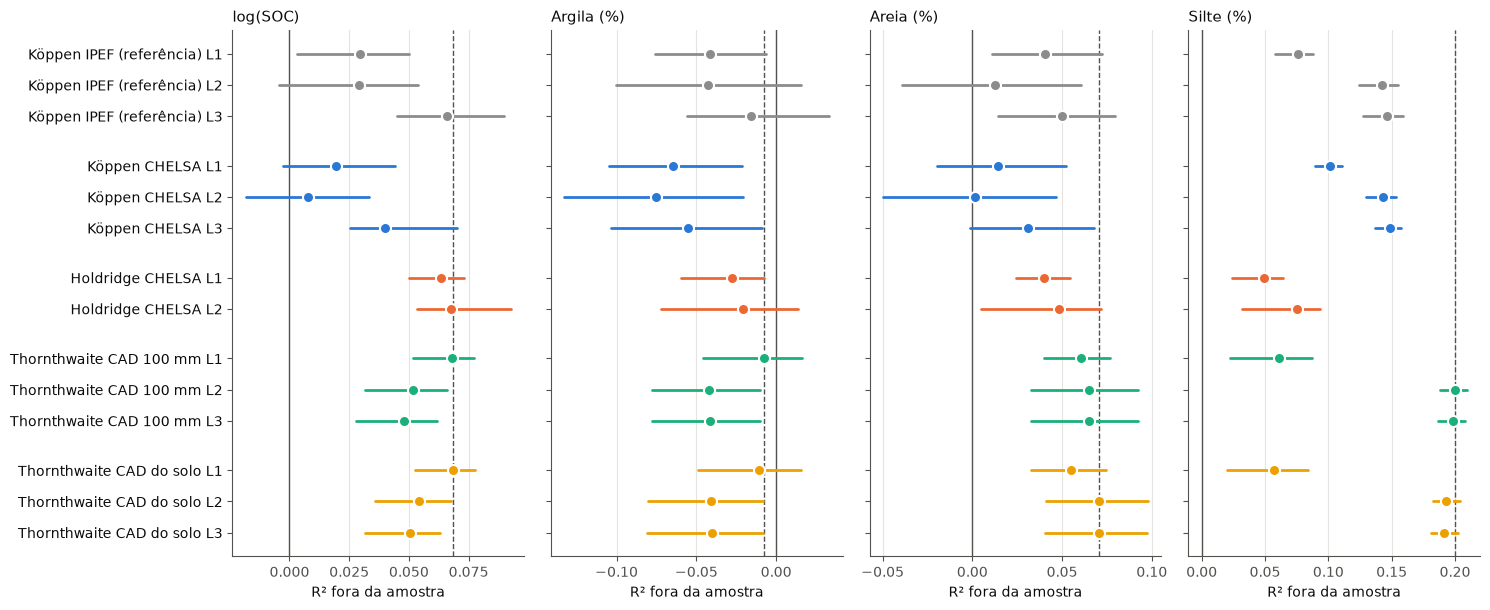

In [3]:
def grafico_r2(esquema='bloco_2'):
    fig, axes = plt.subplots(1, 4, figsize=(15, 6.2), sharey=True)
    ordem = [(s, n) for s in SISTEMAS for n in ('L1', 'L2', 'L3')
             if ((desemp.sistema == s) & (desemp.nivel == n)).any()]
    ypos, y, ult = {}, 0, None
    for s, n in ordem:                       # espaço extra entre sistemas
        y += 1.6 if (ult and ult != s) else 1.0
        ypos[(s, n)] = y
        ult = s
    for ax, (resp, rotulo) in zip(axes, RESPOSTAS.items()):
        d = desemp[desemp.resposta == resp]
        ax.axvline(0, color=TINTA2, lw=1)
        ax.axvline(d[f'r2_{esquema}'].max(), color=TINTA2, lw=1, ls='--')
        for r in d.itertuples():
            yy = ypos[(r.sistema, r.nivel)]
            lo, hi = getattr(r, f'r2_{esquema}_ic_inf'), getattr(r, f'r2_{esquema}_ic_sup')
            ax.plot([lo, hi], [yy, yy], color=CORES[r.sistema], lw=2, solid_capstyle='round')
            ax.plot(getattr(r, f'r2_{esquema}'), yy, 'o', ms=8, color=CORES[r.sistema],
                    markeredgecolor='white', markeredgewidth=1.5)
        ax.set_title(rotulo, color=TINTA, fontsize=11, loc='left')
        ax.grid(axis='x', color=GRADE, lw=0.8)
        ax.set_xlabel('R² fora da amostra')
    axes[0].set_yticks(list(ypos.values()))
    axes[0].set_yticklabels([f'{s} {n}' for s, n in ypos])
    axes[0].invert_yaxis()
    for lbl, (s, _) in zip(axes[0].get_yticklabels(), ypos):
        lbl.set_color(TINTA)
    fig.tight_layout()
    return fig

grafico_r2('bloco_2');
plt.show()

In [4]:
tabela = desemp.pivot_table(index=['sistema', 'nivel', 'n_classes'], columns='resposta',
                            values='r2_bloco_2', sort=False)[list(RESPOSTAS)]
tabela.columns = [f'R² {RESPOSTAS[c]}' for c in tabela.columns]
display(tabela.round(3))

R² log(SOC)  R² Argila (%)  R² Areia (%)  R² Silte (%)
sistema                  nivel n_classes                                                        
Köppen IPEF (referência) L1    3                0.030         -0.041         0.041         0.076
                         L2    8                0.029         -0.043         0.012         0.142
                         L3    10               0.066         -0.015         0.050         0.146
Köppen CHELSA            L1    3                0.019         -0.065         0.014         0.101
                         L2    8                0.008         -0.075         0.001         0.143
                         L3    10               0.040         -0.055         0.031         0.149
Holdridge CHELSA         L1    4                0.064         -0.028         0.040         0.049
                         L2    15               0.068         -0.021         0.048         0.075
Thornthwaite CAD 100 mm  L1    9                0.068         -0.008         0.061         0.061
                         L2    26               0.052         -0.042         0.065         0.200
                         L3    32               0.048         -0.042         0.065         0.198
Thornthwaite CAD do solo L1    9                0.068         -0.011         0.055         0.057
                         L2    26               0.054         -0.041         0.071         0.193
                         L3    32               0.051         -0.040         0.070         0.191

**Leitura, variável por variável:**

- **log(SOC):** todos os sistemas explicam pouco — o melhor fica em R² ≈ 0,07, ou seja, a classe climática
  sozinha explica cerca de 7% da variação do carbono entre locais que ela nunca viu. O grupo de cima tem
  **Thornthwaite L1** (as duas CADs), **Holdridge L1/L2** e **Köppen IPEF L3**, praticamente empatados
  (a seção 6 desempata: o Holdridge L2 se mantém melhor longe das amostras). Köppen CHELSA fica abaixo em
  todos os níveis.
- **Argila:** **nenhum sistema estima argila** fora da amostra: todos ficam com R² ≈ 0 ou negativo. Dentro
  da amostra há alguma associação (ω² de 0,02 a 0,10, seção 8), mas ela não se transfere para regiões
  novas. A argila depende sobretudo do material de origem e do relevo, que o clima atual não captura.
- **Areia:** R² baixos (≤ 0,07). **Thornthwaite L2** lidera, empatado com Holdridge, Köppen IPEF L1/L3 e
  Thornthwaite L1; Köppen CHELSA fica abaixo.
- **Silte:** a variável em que o clima mais explica e a única com vencedor claro: **Thornthwaite L2**
  (R² ≈ 0,20) supera todos os Köppen (≤ 0,15) e o Holdridge (≤ 0,08). O subtipo — em que estação falta ou
  sobra água — é o que faz a diferença: o L1 sozinho cai para 0,06.

Em todas as variáveis, **CAD 100 mm e CAD do solo ficam praticamente sobrepostas.** É esperado: no
equilíbrio anual do balanço hídrico, excedente − deficiência = P − ETP, qualquer que seja a CAD; ela só
redistribui água entre os dois, e a classificação quase não muda.

## 5. As diferenças são reais? Comparação pareada com o melhor

Para cada variável, a tabela mostra quanto o melhor preditor supera cada um dos outros (ΔR², blocos de
2°), com o intervalo de 95% entre as repetições e a proporção de repetições em que o melhor venceu.
**Se o intervalo inclui zero, os dois estão empatados** — a diferença cabe no ruído do sorteio dos blocos.

In [5]:
def empates(resp):
    d = difs[difs.resposta == resp].copy()
    d['empatado'] = d.ic_inf <= 0
    d = d[d.coluna != d.melhor].sort_values('delta_r2')
    return d[['sistema', 'nivel', 'delta_r2', 'ic_inf', 'ic_sup', 'prop_melhor_vence', 'empatado']]

for resp, rotulo in RESPOSTAS.items():
    m = difs[difs.resposta == resp].melhor.iloc[0]
    s, n = desemp.loc[desemp.coluna == m, ['sistema', 'nivel']].iloc[0]
    print(f'{rotulo}: melhor = {s} {n}')
    display(empates(resp).round(3).reset_index(drop=True))

log(SOC): melhor = Thornthwaite CAD do solo L1


,sistema,nivel,delta_r2,ic_inf,ic_sup,prop_melhor_vence,empatado
0,Thornthwaite CAD 100 mm,L1,0.001,-0.000,0.001,0.94,True
1,Holdridge CHELSA,L2,0.001,-0.020,0.017,0.58,True
2,Köppen IPEF (referência),L3,0.002,-0.018,0.021,0.60,True
3,Holdridge CHELSA,L1,0.005,-0.005,0.017,0.74,True
4,Thornthwaite CAD do solo,L2,0.014,0.007,0.026,1.00,False
5,Thornthwaite CAD 100 mm,L2,0.017,0.008,0.029,1.00,False
6,Thornthwaite CAD do solo,L3,0.018,0.011,0.030,1.00,False
7,Thornthwaite CAD 100 mm,L3,0.021,0.012,0.032,1.00,False
8,Köppen CHELSA,L3,0.029,0.001,0.046,0.98,False
9,Köppen IPEF (referência),L1,0.039,0.023,0.059,1.00,False


Argila (%): melhor = Thornthwaite CAD 100 mm L1


,sistema,nivel,delta_r2,ic_inf,ic_sup,prop_melhor_vence,empatado
0,Thornthwaite CAD do solo,L1,0.003,-0.003,0.007,0.86,True
1,Köppen IPEF (referência),L3,0.008,-0.040,0.047,0.62,True
2,Holdridge CHELSA,L2,0.013,-0.019,0.047,0.78,True
3,Holdridge CHELSA,L1,0.020,-0.010,0.047,0.86,True
4,Thornthwaite CAD do solo,L3,0.032,0.003,0.073,0.98,False
5,Thornthwaite CAD do solo,L2,0.033,0.003,0.073,0.98,False
6,Köppen IPEF (referência),L1,0.033,-0.020,0.078,0.90,True
7,Thornthwaite CAD 100 mm,L3,0.034,0.002,0.077,0.98,False
8,Thornthwaite CAD 100 mm,L2,0.034,0.003,0.076,0.98,False
9,Köppen IPEF (referência),L2,0.035,-0.025,0.089,0.82,True


Areia (%): melhor = Thornthwaite CAD do solo L2


,sistema,nivel,delta_r2,ic_inf,ic_sup,prop_melhor_vence,empatado
0,Thornthwaite CAD do solo,L3,0.000,-0.000,0.001,0.68,True
1,Thornthwaite CAD 100 mm,L2,0.005,0.000,0.012,0.98,False
2,Thornthwaite CAD 100 mm,L3,0.006,0.000,0.013,1.00,False
3,Thornthwaite CAD 100 mm,L1,0.010,-0.027,0.036,0.68,True
4,Thornthwaite CAD do solo,L1,0.016,-0.024,0.043,0.80,True
5,Köppen IPEF (referência),L3,0.021,-0.008,0.062,0.72,True
6,Holdridge CHELSA,L2,0.022,-0.012,0.079,0.84,True
7,Köppen IPEF (referência),L1,0.030,-0.010,0.057,0.96,True
8,Holdridge CHELSA,L1,0.031,-0.004,0.064,0.94,True
9,Köppen CHELSA,L3,0.039,0.007,0.077,1.00,False


Silte (%): melhor = Thornthwaite CAD 100 mm L2


,sistema,nivel,delta_r2,ic_inf,ic_sup,prop_melhor_vence,empatado
0,Thornthwaite CAD 100 mm,L3,0.002,0.001,0.002,1.0,False
1,Thornthwaite CAD do solo,L2,0.007,0.002,0.012,1.0,False
2,Thornthwaite CAD do solo,L3,0.009,0.003,0.014,1.0,False
3,Köppen CHELSA,L3,0.051,0.038,0.064,1.0,False
4,Köppen IPEF (referência),L3,0.054,0.043,0.067,1.0,False
5,Köppen CHELSA,L2,0.057,0.043,0.070,1.0,False
6,Köppen IPEF (referência),L2,0.058,0.046,0.071,1.0,False
7,Köppen CHELSA,L1,0.099,0.090,0.110,1.0,False
8,Köppen IPEF (referência),L1,0.124,0.114,0.141,1.0,False
9,Holdridge CHELSA,L2,0.125,0.104,0.161,1.0,False


**Leitura:**

- **SOC:** o melhor nos blocos de 2° (Thornthwaite CAD do solo L1) empata com Thornthwaite CAD 100 mm L1,
  Holdridge L1 e L2 e Köppen IPEF L3. Supera com folga o Köppen CHELSA e os L2/L3 do Thornthwaite (classes demais para o
  pouco sinal que o SOC tem).
- **Argila:** vários "empates", mas eles são empates em torno de zero: nenhum sistema tem R² espacial
  positivo com segurança. Não há sistema melhor para argila; há só sistemas menos ruins.
- **Areia:** Thornthwaite L2 (CAD do solo) empata com Thornthwaite L1, Holdridge e Köppen IPEF L1/L3; vence
  o Köppen CHELSA.
- **Silte:** Thornthwaite L2 vence **todos** os outros sistemas em 100% das repetições; entre as duas
  CADs a diferença é desprezível (ΔR² < 0,01).

## 6. Por que validar em blocos: o R² cai quando o teste fica longe do treino

O gráfico mostra, para o melhor nível de cada sistema, o R² em cada esquema de validação: dobras
aleatórias (locais vizinhos podem estar um no treino e outro no teste) e blocos de 1°, 2° e 5°.

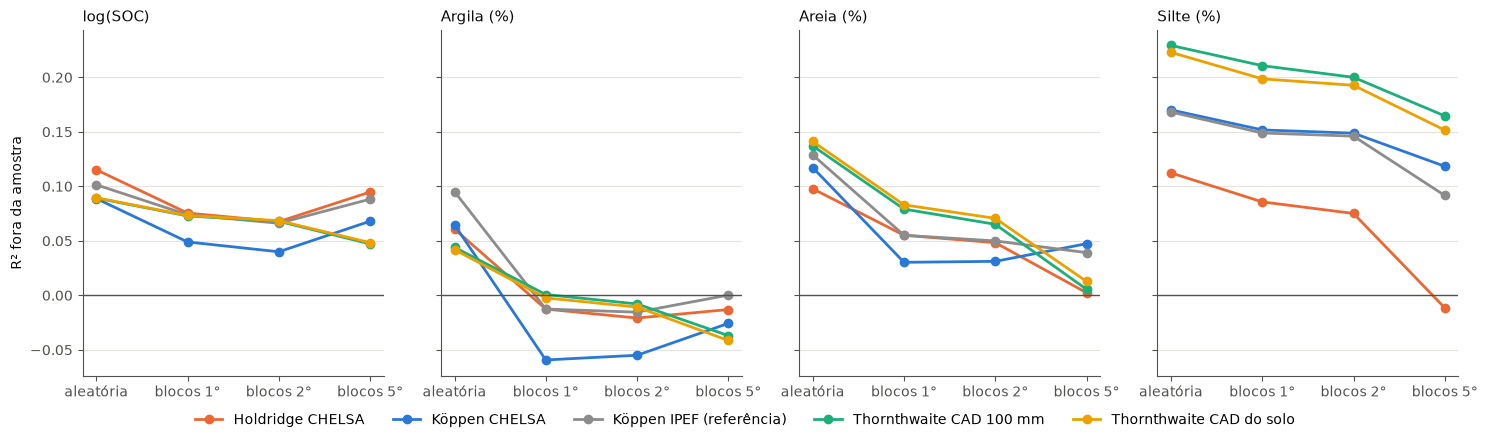

In [6]:
ESQUEMAS = {'aleatoria': 'aleatória', 'bloco_1': 'blocos 1°', 'bloco_2': 'blocos 2°', 'bloco_5': 'blocos 5°'}
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharey=True)
for ax, (resp, rotulo) in zip(axes, RESPOSTAS.items()):
    d = desemp[desemp.resposta == resp]
    melhores = d.loc[d.groupby('sistema').r2_bloco_2.idxmax()]
    for r in melhores.itertuples():
        vals = [getattr(r, f'r2_{e}') for e in ESQUEMAS]
        ax.plot(range(4), vals, '-o', color=CORES[r.sistema], lw=2, ms=6,
                label=f'{r.sistema} {r.nivel}')
    ax.axhline(0, color=TINTA2, lw=1)
    ax.set_xticks(range(4), list(ESQUEMAS.values()))
    ax.set_title(rotulo, color=TINTA, fontsize=11, loc='left')
    ax.grid(axis='y', color=GRADE, lw=0.8)
axes[0].set_ylabel('R² fora da amostra')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, [l.split(' L')[0] for l in labels], loc='lower center', ncol=5, frameon=False,
           bbox_to_anchor=(0.5, -0.06))
fig.tight_layout()
plt.show()

**Leitura:**

- Com dobras **aleatórias**, o R² é praticamente igual ao ω² dentro da amostra — o teste sempre tem um
  vizinho no treino, e o resultado é otimista. Em argila, por exemplo, todos parecem explicar 2-10%, o que
  desaparece nos blocos.
- **Silte:** o Thornthwaite L2 lidera em todos os esquemas, inclusive nos blocos de 5° (≈ 0,16, contra
  ≈ 0,12 do Köppen). É a escolha mais segura do estudo.
- **SOC:** a ordem muda com a distância. Nos blocos de 1° e 2° há empate; nos de **5°** o Thornthwaite L1
  cai para ≈ 0,05, enquanto o **Holdridge L2 sobe para ≈ 0,10** e o Köppen IPEF L3 fica em ≈ 0,09. Para
  estimar SOC em regiões sem amostras próximas, o Holdridge L2 é o mais robusto — por isso é o recomendado.
- **Areia:** o Thornthwaite lidera a 1° e 2°, mas a 5° praticamente zera e quem fica na frente é o Köppen
  IPEF L1 (≈ 0,07). O sinal é fraco demais para eleger um vencedor.
- Os blocos de 5° têm só ~44 blocos, então esse esquema é mais ruidoso; ele serve como teste de robustez,
  não como métrica principal.

## 7. O que as classes mostram

Mediana de SOC e de silte por classe de umidade de Thornthwaite (CAD 100 mm, L1), da mais úmida (A) para
a mais seca (E). É a parte interpretável do resultado: o que a classe "sabe" sobre o solo.

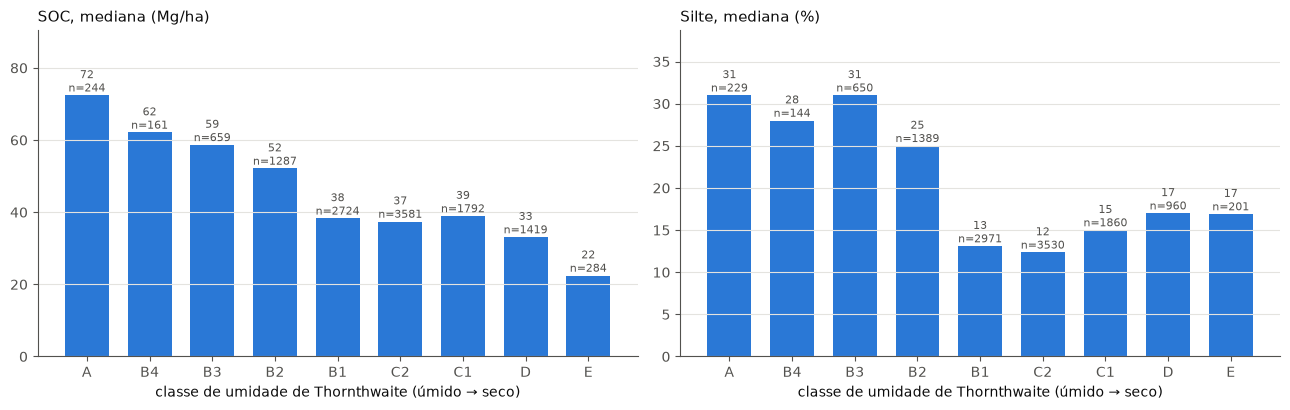

ω² log(SOC)  ω² Argila (%)  ω² Areia (%)  ω² Silte (%)
sistema                  nivel                                                        
Köppen IPEF (referência) L1           0.059          0.033         0.088         0.091
                         L2           0.070          0.061         0.096         0.164
                         L3           0.102          0.096         0.130         0.169
Köppen CHELSA            L1           0.056          0.021         0.076         0.114
                         L2           0.061          0.035         0.090         0.167
                         L3           0.090          0.065         0.118         0.171
Holdridge CHELSA         L1           0.083          0.025         0.071         0.077
                         L2           0.117          0.061         0.099         0.114
Thornthwaite CAD 100 mm  L1           0.090          0.045         0.094         0.106
                         L2           0.096          0.067         0.139         0.232
                         L3           0.096          0.069         0.140         0.231
Thornthwaite CAD do solo L1           0.090          0.043         0.090         0.103
                         L2           0.095          0.068         0.143         0.225
                         L3           0.095          0.069         0.144         0.225

In [7]:
ORDEM_UMIDADE = ['A', 'B4', 'B3', 'B2', 'B1', 'C2', 'C1', 'D', 'E']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (resp, rotulo) in zip(axes, [('log_soc', 'SOC, mediana (Mg/ha)'), ('silte', 'Silte, mediana (%)')]):
    d = (classes[(classes.resposta == resp) & (classes.coluna == 'th100_l1')]
         .set_index('classe').reindex(ORDEM_UMIDADE).dropna(subset=['n']))
    x = np.arange(len(d))
    ax.bar(x, d.mediana, width=0.7, color='#2a78d6')
    for xi, (med, n) in enumerate(zip(d.mediana, d.n)):
        ax.text(xi, med, f'{med:.0f}\nn={int(n)}', ha='center', va='bottom', fontsize=8, color=TINTA2)
    ax.set_xticks(x, d.index)
    ax.set_title(rotulo, color=TINTA, fontsize=11, loc='left')
    ax.set_xlabel('classe de umidade de Thornthwaite (úmido → seco)')
    ax.grid(axis='y', color=GRADE, lw=0.8)
    ax.set_ylim(0, d.mediana.max() * 1.25)
fig.tight_layout()
plt.show()

omega = desemp.pivot_table(index=['sistema', 'nivel'], columns='resposta', values='omega2', sort=False)[list(RESPOSTAS)]
omega.columns = [f'ω² {RESPOSTAS[c]}' for c in omega.columns]
display(omega.round(3))

**Leitura:** o SOC cai do clima mais úmido para o mais seco — de ≈ 72 Mg/ha na classe A para ≈ 22 Mg/ha
na E, com um patamar em ≈ 38 Mg/ha entre B1 e C1. É o gradiente de umidade que a classificação de
Thornthwaite organiza diretamente. O silte separa dois grupos: climas úmidos (A a B2, ≈ 25-31%) e os
demais (≈ 12-17%); o subtipo (L2, a estação em que falta ou sobra água) refina essa separação, e é por
isso que o L2 é o melhor preditor de silte.

Na tabela de ω² (dentro da amostra), os valores são maiores que os R² espaciais — exatamente o otimismo
que a validação em blocos corrige. Serve para descrever a associação, não para escolher o sistema.

## 8. Conclusão e recomendação

1. **Não há um sistema único melhor; a base depende da variável.**
   - **SOC → Holdridge L2 (zona de vida).** Empata com os melhores a curta distância e é o que se mantém
     melhor longe das amostras (blocos de 5°). Thornthwaite L1 é uma alternativa equivalente a curta
     distância.
   - **Textura → Thornthwaite L2 (umidade + subtipo).** Único vencedor claro e robusto do estudo (silte).
     Em areia o sinal é fraco; em argila, nenhum sistema funciona. O L3 não acrescenta nada (as letras
     térmicas são quase constantes com ETP de Penman-Monteith).
   - **CAD do Thornthwaite:** tanto faz. CAD 100 mm é mais simples e não depende do mapa de AWC (que tem
     lacunas em corpos d'água e no litoral).
2. **Se for preciso um sistema só para tudo,** o Thornthwaite L2 é o que menos perde: fica no grupo de
   cima em SOC a curta distância e vence em textura. O custo é perder robustez em SOC longe das amostras.
3. **Köppen CHELSA não é recomendado:** fica abaixo do Köppen IPEF, que as matrizes já trazem, em todas
   as variáveis. Trocar o IPEF pelo CHELSA pioraria a base.
4. **A ressalva principal:** classe climática sozinha explica pouco. Para SOC o teto é ≈ 7-10% fora da
   amostra; para argila, nada. A escolha do sistema melhora a base, mas o grosso da variação do solo vem
   de outros fatores (material de origem, relevo, uso da terra, vegetação).

**Limitações:**

- **Distribuição dos pontos:** os locais não são uma amostra aleatória do Brasil (há mais pontos no Sul e
  Sudeste e menos na Amazônia). As médias por classe refletem essa distribuição.
- **Uma variável de cada vez:** cada sistema foi avaliado como único preditor. Num modelo com outras
  covariáveis, a contribuição do clima pode ser menor, porque parte da informação é compartilhada.
- **Escala:** o clima está a ~1 km (CHELSA) e o solo é medido no ponto. A variação de solo dentro de um
  pixel de clima fica sem explicação por construção.

## 9. Como reproduzir

```bash
python codigo/preparar_dados.py     # GEE: baixa as matrizes (acesso restrito) e amostra os climas -> .local/dados/
python codigo/comparar_climas.py    # métricas -> resultados/tabelas/*.csv (~20 s)
python -m pytest codigo             # testes do método com dados sintéticos
```

Este notebook lê só `resultados/tabelas/` e roda sem GEE e sem os dados por ponto (que são restritos e não
vão para o git). Os assets climáticos são gerados em `climas/chelsa_climas_brasil/` (notebooks de Köppen,
Holdridge e Thornthwaite).